# Блок заданий 06: методы без учителя

## Вспомогательный код

*(Можно не смотреть, но надо запустить)*

In [41]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from scipy import stats

In [42]:
ok = set()  # это служебная структура, чтобы Вам было проще смотреть все ли задания выполнены
all_tasks = (
    {'1.0', '1.1', '1.2'}
)

Код из прошлого занятия:

In [43]:
from sklearn.base import BaseEstimator, TransformerMixin, ClusterMixin, RegressorMixin
from numbers import Real, Integral

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, f1_score, average_precision_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier


# на случай, если версия sklearn отличается очень существенно используем такой хак:
try:
    from sklearn.base import _fit_context
    from sklearn.utils._param_validation import StrOptions, Interval
except:
    _fit_context = lambda **kwargs: lambda fn: fn
    StrOptions = lambda _: None

try:
    from sklearn.utils import check_X_y
    from sklearn.utils import check_random_state
except:
    check_X_y = lambda X, y: None
    check_random_state = lambda rs: np.random.RandomState(rs)


## Задания

#### 1.0. Построение устойчивой линейной модели

**Задача:** постройте линейную модель, не учитывающую выбросы.
Для простоты рассматривается линейная регрессия с одним признаком: $x \in \mathbb{R}, y \in \mathbb{R}$.

**Требуется** построить модель без учёта выбросов.

- *Для решения можно использовать любые методы из библиотеки scikit-learn.*
- *Посмотрите [RANSAC](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RANSACRegressor.html).*

**Генерация данных (не менять)**:

In [44]:
rng_1_0 = np.random.default_rng(1)
X_1_0 = rng_1_0.choice(
    np.concatenate([rng_1_0.uniform(0, 1, size=500), rng_1_0.normal(0.7, 0.01, size=500)], axis=0),
    1000,
    replace=True
)[:, None]
gt_w = 2.39
gt_b = 3.0
noise_ind = rng_1_0.choice(2, size=X_1_0.shape[0], p=[0.4, 0.6])
y_1_0 = np.where(
    noise_ind[:, None],
    gt_w * X_1_0 + gt_b,
    rng_1_0.normal(gt_b, 1.0, size=X_1_0.shape)
)

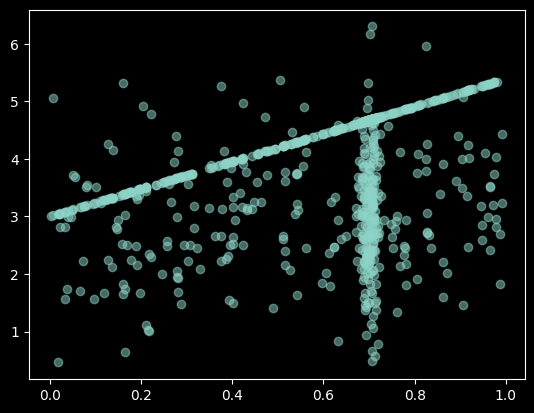

In [45]:
plt.scatter(X_1_0[:, 0], y_1_0, alpha=0.5)

**Ваше решение:**

In [46]:
from sklearn.linear_model import RANSACRegressor

model = RANSACRegressor(estimator=LinearRegression(), random_state=1)
model.fit(X_1_0, y_1_0)  # можно менять


,"estimator estimator: object, default=NoneBase estimator object which implements the following methods:* `fit(X, y)`: Fit model to given training data and target values.* `score(X, y)`: Returns the mean accuracy on the given test data, which is used for the stop criterion defined by `stop_score`. Additionally, the score is used to decide which of two equally large consensus sets is chosen as the better one.* `predict(X)`: Returns predicted values using the linear model, which is used to compute residual error using loss function.If `estimator` is None, then:class:`~sklearn.linear_model.LinearRegression` is used fortarget values of dtype float.Note that the current implementation only supports regressionestimators.",LinearRegression()
,"min_samples min_samples: int (>= 1) or float ([0, 1]), default=NoneMinimum number of samples chosen randomly from original data. Treatedas an absolute number of samples for `min_samples >= 1`, treated as arelative number `ceil(min_samples * X.shape[0])` for`min_samples < 1`. This is typically chosen as the minimal number ofsamples necessary to estimate the given `estimator`. By default a:class:`~sklearn.linear_model.LinearRegression` estimator is assumed and`min_samples` is chosen as ``X.shape[1] + 1``. This parameter is highlydependent upon the model, so if a `estimator` other than:class:`~sklearn.linear_model.LinearRegression` is used, the user mustprovide a value.",None
,"residual_threshold residual_threshold: float, default=NoneMaximum residual for a data sample to be classified as an inlier.By default the threshold is chosen as the MAD (median absolutedeviation) of the target values `y`. Points whose residuals arestrictly equal to the threshold are considered as inliers.",None
,"is_data_valid is_data_valid: callable, default=NoneThis function is called with the randomly selected data before themodel is fitted to it: `is_data_valid(X, y)`. If its return value isFalse the current randomly chosen sub-sample is skipped.",None
,"is_model_valid is_model_valid: callable, default=NoneThis function is called with the estimated model and the randomlyselected data: `is_model_valid(model, X, y)`. If its return value isFalse the current randomly chosen sub-sample is skipped.Rejecting samples with this function is computationally costlier thanwith `is_data_valid`. `is_model_valid` should therefore only be used ifthe estimated model is needed for making the rejection decision.",None
,"max_trials max_trials: int, default=100Maximum number of iterations for random sample selection.",100
,"max_skips max_skips: int, default=np.infMaximum number of iterations that can be skipped due to finding zeroinliers or invalid data defined by ``is_data_valid`` or invalid modelsdefined by ``is_model_valid``... versionadded:: 0.19",inf
,"stop_n_inliers stop_n_inliers: int, default=np.infStop iteration if at least this number of inliers are found.",inf
,"stop_score stop_score: float, default=np.infStop iteration if score is greater equal than this threshold.",inf
,"stop_probability stop_probability: float in range [0, 1], default=0.99RANSAC iteration stops if at least one outlier-free set of the trainingdata is sampled in RANSAC. This requires to generate at least Nsamples (iterations):: N >= log(1 - probability) / log(1 - e**m)where the probability (confidence) is typically set to high value suchas 0.99 (the default) and e is the current fraction of inliers w.r.t.the total number of samples.",0.99
,"loss loss: str, callable, default='absolute_error'String inputs, 'absolute_error' and 'squared_error' are supported whichfind the absolute error and squared error per sample respectively.If ``loss`` is a callable, then it should be a function that takestwo arrays as inputs, the true and predicted value and returns a 1-Darray with the i-th value of the array corresponding to the losson ``X[i]``.If the loss on a sample is greater than the ``residual_threshold``,then this sample is classified as an outlier... versionadded:: 0.18"

In [ ]:
# ваш код для проверки модели, если требуется

Визуализация:

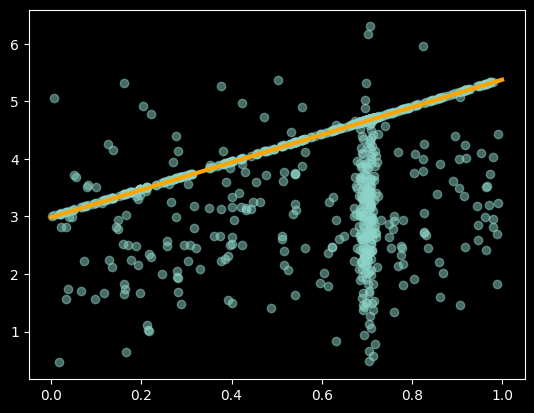

In [47]:
t = np.linspace(0., 1.)[:, np.newaxis]
plt.scatter(X_1_0, y_1_0, alpha=0.5)
plt.plot(t, model.predict(t), c='orange', linewidth=3)

Проверки, что задание выполнено верно:

In [48]:
t = np.linspace(0., 1.)[:, np.newaxis]
predictions = model.predict(t)
est_w = LinearRegression().fit(t, predictions).coef_[0]
assert abs(est_w - gt_w) < 1.e-1, 'Задача должна быть решена верно'

ok.add('1.0')

#### 1.1. Устойчивое определение подпространства

**Задача:** в наборе данных содержится множество линейно коррелированных признаков (коэффициент корреляции около $\pm 1$), при этом иногда встречаются выбросы, где признаки являются произвольными.

**Требуется**, игнорируя выбросы, понизить размерность и определить две функции:

- `transform(X)`, возвращающую преобразованные данные (минимальной размерности, при которой не теряется информация);
- `inverse_transform(Z)`, восстанавливающую `X` по данным низкой размерности, т.е.
$\text{inverse\_transform}(\text{transform}(X)) \approx X$.

С помощью данной комбинации функций должно быть возможно определить какие примеры являются выбросами.

*Замечания:*
- *Для решения можно использовать любые методы из библиотеки scikit-learn.*
- *Посмотрите [RANSAC](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RANSACRegressor.html).*
- *Для нахождения подпространства естественно использовать `PCA`.*

**Генерация данных (не менять)**:

In [49]:
rng_1_1 = np.random.default_rng(1)
orig_X_1_1 = rng_1_1.uniform(0, 1, size=(1000, 3))
gt_transform = np.array([
    [1., 0., 0.],
    [0., 1., 0.],
    [0., 0., 1.],
    [-2., 0., 0.],
    [0., 1., -1.],
]).T
X_1_1 = orig_X_1_1 @ gt_transform
noise_ind = rng_1_1.choice(2, size=X_1_1.shape[0], p=[0.1, 0.9])
X_1_1 = np.where(
    noise_ind[:, None],
    X_1_1,
    rng_1_1.normal(0.0, 0.25, size=X_1_1.shape)
)

**Визуализация** признаков $(x_1, x_2, x_4)$:

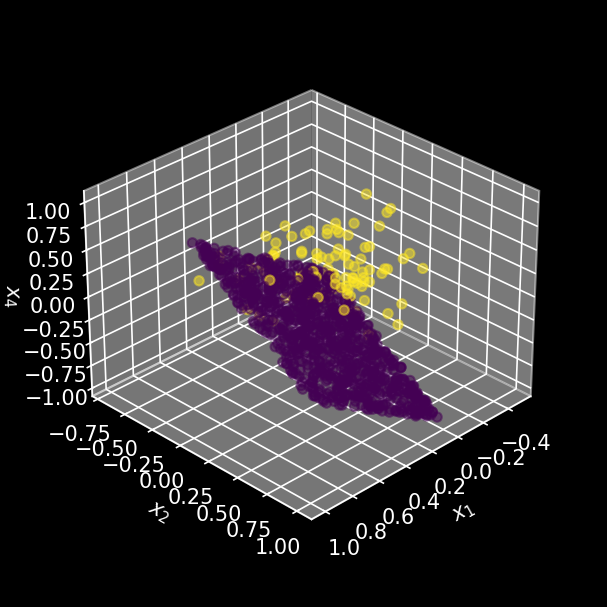

In [50]:
fig = plt.figure(figsize=(5, 5), dpi=150)
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X_1_1[:, 1], X_1_1[:, 2], X_1_1[:, 4], c=1 - noise_ind, alpha=0.5)
ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_zlabel('$x_4$')
ax.view_init(elev=30, azim=45)
ax.set_box_aspect(None, zoom=0.85)

**Ваше решение:**

In [51]:
from sklearn.linear_model import RANSACRegressor
from sklearn.multioutput import MultiOutputRegressor
from sklearn.decomposition import PCA

ransac_xy = MultiOutputRegressor(
    RANSACRegressor(
        estimator=LinearRegression(),
        random_state=1,
        max_trials=500,
        min_samples=10,
    )
)
ransac_xy.fit(X_1_1[:, :3], X_1_1[:, 3:])
inlier_mask = ransac_xy.estimators_[0].inlier_mask_ & ransac_xy.estimators_[1].inlier_mask_
_pca = PCA(n_components=3).fit(X_1_1[inlier_mask])

transform = _pca.transform
inverse_transform = _pca.inverse_transform


In [ ]:
# ваш код для проверки модели, если требуется

Проверки, что задание выполнено верно:

In [68]:
clean_X = X_1_1[noise_ind.astype(bool)]
transformed = transform(clean_X)
assert transformed.shape[1] == 3, 'В данном случае число компонент должно быть равно 3'
assert np.abs(inverse_transform(transformed) - clean_X).max() < 0.1, 'Данные (кроме выбросов) должны хорошо восстанавливаться'

recon_err = np.abs(inverse_transform(transform(X_1_1)) - X_1_1).max(axis=1)[:, np.newaxis]
tree = DecisionTreeClassifier(max_depth=1)
tree.fit(recon_err, noise_ind)
assert accuracy_score(noise_ind, tree.predict(recon_err)) > 0.99, \
    'Должна быть возможность легко определить выбросы по ошибке реконструкции'

ok.add('1.1') # тут было 1.0!!

#### 1.2. Жизненная задача: аномалии

**Задача:** есть набор данных с большим числом признаков (от некоторого заказчика), их семантика неизвестна. Заказчик предоставил классификационную разметку только для части данных (в текстовом формате), но дал описание. Данные содержат множество взаимосвязанных признаков, а классификационная метка равна $1$, когда встречается аномалия. Число размеченных данных невелико, но также предоставляется большое число неразмеченных данных.

На вход даны файлы `06_1.2.X_train.txt, 06_1.2.y_train.txt, 06_1.2.X_val.txt, 06_1.2.y_val.txt`.
В файле `06_1.2.y_train.txt` содержится разметка первых 20 примеров из `06_1.2.X_train.txt`.
**Валидационные даннные нельзя использовать для обучения модели**.

**Требуется** построить наиболее точный классификатор (по метрике AUROC), а также дать объяснение как определяется "аномальность" данных.

- *Для решения можно использовать любые методы из библиотеки scikit-learn.*
- *Используйте данные без разметки и информацию о том, как принимается решение.*

**Загрузите данные:**

*(Используйте подходящие типы данных)*

In [53]:
X_train = np.loadtxt("06_1.2.X_train.txt")
y_train = np.loadtxt("06_1.2.y_train.txt", dtype=np.int64)

X_val = np.loadtxt("06_1.2.X_val.txt")
y_val = np.loadtxt("06_1.2.y_val.txt", dtype=np.int64)


**Посмотрите на данные:**

In [54]:
print("X_train", X_train.shape, "y_train", y_train.shape)
print("X_val", X_val.shape, "y_val", y_val.shape)
print("y_train counts", np.unique(y_train, return_counts=True))
print("y_val counts", np.unique(y_val, return_counts=True))


X_train (55500, 120) y_train (20,)
X_val (200, 120) y_val (200,)
y_train counts (array([0, 1]), array([19,  1]))
y_val counts (array([0, 1]), array([160,  40]))


**Метрики:**

In [55]:
from sklearn.preprocessing import LabelEncoder

In [56]:
def calc_metrics(y_true, proba_pred, label_enc=None):
    if proba_pred.shape[1] == 2:
        proba_pred = proba_pred[:, 1]
    if label_enc is None:
        label_enc = LabelEncoder().fit(y_true)
    if proba_pred.ndim == 1:
        label_pred = label_enc.inverse_transform(np.where(proba_pred >= 0.5, 1, 0))
    else:
        label_pred = label_enc.inverse_transform(np.argmax(proba_pred, axis=1))
    return {
        'Acc': accuracy_score(y_true, label_pred),
        'AUROC': roc_auc_score(y_true, proba_pred),
        'AP': average_precision_score(y_true, proba_pred),
        'F1': f1_score(y_true, label_pred),
    }
    

**Ваше решение:**

*Должно включать всю предобработку данных, чтобы по новому набору данных (из того же источника, распределения) можно было построить новую модель. Т.е. весь код предобработки должен быть встроен в класс `Solution`.*

In [57]:
class Solution:
    def fit(self, X, y):
        """Fit the model.
        
        Args:
            X: Input features of shape (n_samples, n_features).
            y: Training labels, of shape (n_labeled_samples). Where n_labeled_samples < n_samples.

        """
        from sklearn.preprocessing import StandardScaler
        from sklearn.ensemble import IsolationForest
        from sklearn.linear_model import LogisticRegression

        self._scaler = StandardScaler()
        Xs = self._scaler.fit_transform(X)

        self._iforest = IsolationForest(
            n_estimators=500,
            max_samples=256,
            random_state=0,
        )
        self._iforest.fit(Xs)
        s = (-self._iforest.score_samples(Xs)).reshape(-1, 1)

        self._lr = LogisticRegression(max_iter=5000, class_weight="balanced", random_state=0)
        self._lr.fit(s[: y.shape[0]], y.astype(np.int64, copy=False))

        return self

    def predict_proba(self, X):
        """
        Args:
            X: Input features of shape (n_samples, n_features).

        Returns:
            Matrix, where each row contains probabilities of classes, of shape (n_samples, n_classes).
            In case of binary classification, returns (n_samples, 2).

        """
        Xs = self._scaler.transform(X)
        s = (-self._iforest.score_samples(Xs)).reshape(-1, 1)
        return self._lr.predict_proba(s)


Создаём модель, затем обучаем:

In [58]:
solution = Solution()
solution.fit(X_train, y_train)

In [ ]:
# ваш код для проверки модели, если требуется

In [59]:
results_df = pd.DataFrame({
    'Train': calc_metrics(y_train, solution.predict_proba(X_train[:y_train.shape[0]])),
    'Val': calc_metrics(y_val, solution.predict_proba(X_val)),
})


Проверки, что задание выполнено верно:

In [63]:
assert isinstance(solution, Solution), 'Модель должна быть нужного класса'
predictions = solution.predict_proba(X_val)
assert roc_auc_score(y_val, predictions[:, 1]) > 0.99, 'Задача должна быть решена верно'

ok.add('1.2')

**Ваше объяснение как определяется *аномальность* в данной задаче:**

Аномальность отклонение от распределения признаков score_samples чем ниже тем сильнее объект дальше от остальных. 

## Итоги

In [70]:
print(f'Выполнены задания: {ok}')
print(f'Осталось: {all_tasks - ok}')
print(f'Выполнено: {len(ok)}. Не выполнено: {len(all_tasks - ok)}')
print('в 1.1 была ошибка, 1.0 добавлялось в множество ')

Выполнены задания: {'1.2', '1.0', '1.1'}
Осталось: set()
Выполнено: 3. Не выполнено: 0
в 1.1 была ошибка, 1.0 добавлялось в множество 
